In [ ]:
import pprint as p
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import folium
from folium.raster_layers import ImageOverlay

In [3]:
def load_and_clean_weather_data(url):
    """Loads data from a NOAA CSV URL and converts units."""
    df = pd.read_csv(url, low_memory=False)

    # Check for required columns
    required_cols = ['TMIN', 'TMAX', 'PRCP', 'SNOW']
    for col in required_cols:
        if col not in df.columns:
            print(f"Warning: '{col}' column not found in data. Skipping this column.")

    # Convert date format
    df['DATE'] = pd.to_datetime(df['DATE'])

    # Convert units (mm/10 -> mm/cm, inch, C)
    if 'SNOW' in df.columns:
        df['SNOW_INCH'] = df['SNOW'] / 25.4
        df['SNOW(cm)'] = df['SNOW'] / 10

    if 'TMAX' in df.columns:
        df['TMAX(C)'] = df['TMAX'] / 10

    if 'TMIN' in df.columns:
        df['TMIN(C)'] = df['TMIN'] / 10

    if 'PRCP' in df.columns:
        df['PRCP(mm)'] = df['PRCP'] / 10

    return df

def get_selected_weather_cols(df):
    """Filters and returns key columns for analysis based on their names."""
    # Specifying column names directly is the safest approach.
    desired_cols = [
        'STATION', 'NAME', 'DATE', 'PRCP(mm)',
        'SNOW(cm)', 'SNWD', 'TMAX(C)', 'TMIN(C)', 'SNOW_INCH'
    ]

    # Select only columns that actually exist in the DataFrame
    available_cols = [col for col in desired_cols if col in df.columns]

    return df[available_cols]

def get_snowfall_events(df):
    """Extracts data for days with snowfall (SNOW_INCH > 0)."""
    if 'SNOW_INCH' in df.columns:
        # Filter where SNOW_INCH is not NaN and greater than 0
        return df[df['SNOW_INCH'].notnull() & (df['SNOW_INCH'] > 0)][['DATE', 'SNOW_INCH']]
    else:
        print("Warning: 'SNOW_INCH' column not found, unable to retrieve snowfall events.")
        return pd.DataFrame(columns=['DATE', 'SNOW_INCH'])

In [4]:
# Example of processing Seattle data using functions
url_seattle = 'https://www.ncei.noaa.gov/data/global-historical-climatology-network-daily/access/USW00024233.csv'
df_seattle_raw = load_and_clean_weather_data(url_seattle)
df_seattle_final = get_selected_weather_cols(df_seattle_raw)
every_snowfall_seattle = get_snowfall_events(df_seattle_raw)

print("Seattle data processing complete!")
display(df_seattle_final.head(3))

Seattle data processing complete!


,STATION,NAME,DATE,PRCP(mm),SNOW(cm),SNWD,TMAX(C),TMIN(C),SNOW_INCH
0,USW00024233,"SEATTLE TACOMA AIRPORT, WA US",1948-01-01,11.9,0.0,0.0,10.6,5.6,0.0
1,USW00024233,"SEATTLE TACOMA AIRPORT, WA US",1948-01-02,15.0,0.0,0.0,7.2,2.2,0.0
2,USW00024233,"SEATTLE TACOMA AIRPORT, WA US",1948-01-03,10.7,0.0,0.0,7.2,1.7,0.0


In [9]:
# Example of processing Everett data using functions
url_everett = 'https://www.ncei.noaa.gov/data/global-historical-climatology-network-daily/access/USW00024222.csv'
df_everett_raw = load_and_clean_weather_data(url_everett)
df_everett_final = get_selected_weather_cols(df_everett_raw)
every_snowfall_everett = get_snowfall_events(df_everett_raw)

print("Everett data processing complete!")
display(df_everett_final.head(3))

Everett data processing complete!


,STATION,NAME,DATE,PRCP(mm),SNOW(cm),SNWD,TMAX(C),TMIN(C),SNOW_INCH
0,USW00024222,"EVERETT SNOHOMISH CO AIRPORT, WA US",1948-01-01,18.8,0.0,0.0,8.9,3.9,0.0
1,USW00024222,"EVERETT SNOHOMISH CO AIRPORT, WA US",1948-01-02,4.3,0.0,0.0,7.2,1.7,0.0
2,USW00024222,"EVERETT SNOHOMISH CO AIRPORT, WA US",1948-01-03,7.1,0.0,0.0,6.7,2.2,0.0


In [7]:
# Example of processing Monroe data using functions
url_monroe = 'https://www.ncei.noaa.gov/data/global-historical-climatology-network-daily/access/USC00455525.csv'
df_monroe_raw = load_and_clean_weather_data(url_monroe)
df_monroe_final = get_selected_weather_cols(df_monroe_raw)
every_snowfall_monroe = get_snowfall_events(df_monroe_raw)

print("Monroe data processing complete!")
display(df_monroe_final.head(3))

Monroe data processing complete!


,STATION,NAME,DATE,PRCP(mm),SNOW(cm),SNWD,TMAX(C),TMIN(C),SNOW_INCH
0,USC00455525,"MONROE, WA US",1929-02-01,20.1,20.1,NaN,NaN,NaN,7.913386
1,USC00455525,"MONROE, WA US",1929-02-02,0.0,NaN,NaN,NaN,NaN,NaN
2,USC00455525,"MONROE, WA US",1929-02-03,0.0,NaN,NaN,NaN,NaN,NaN


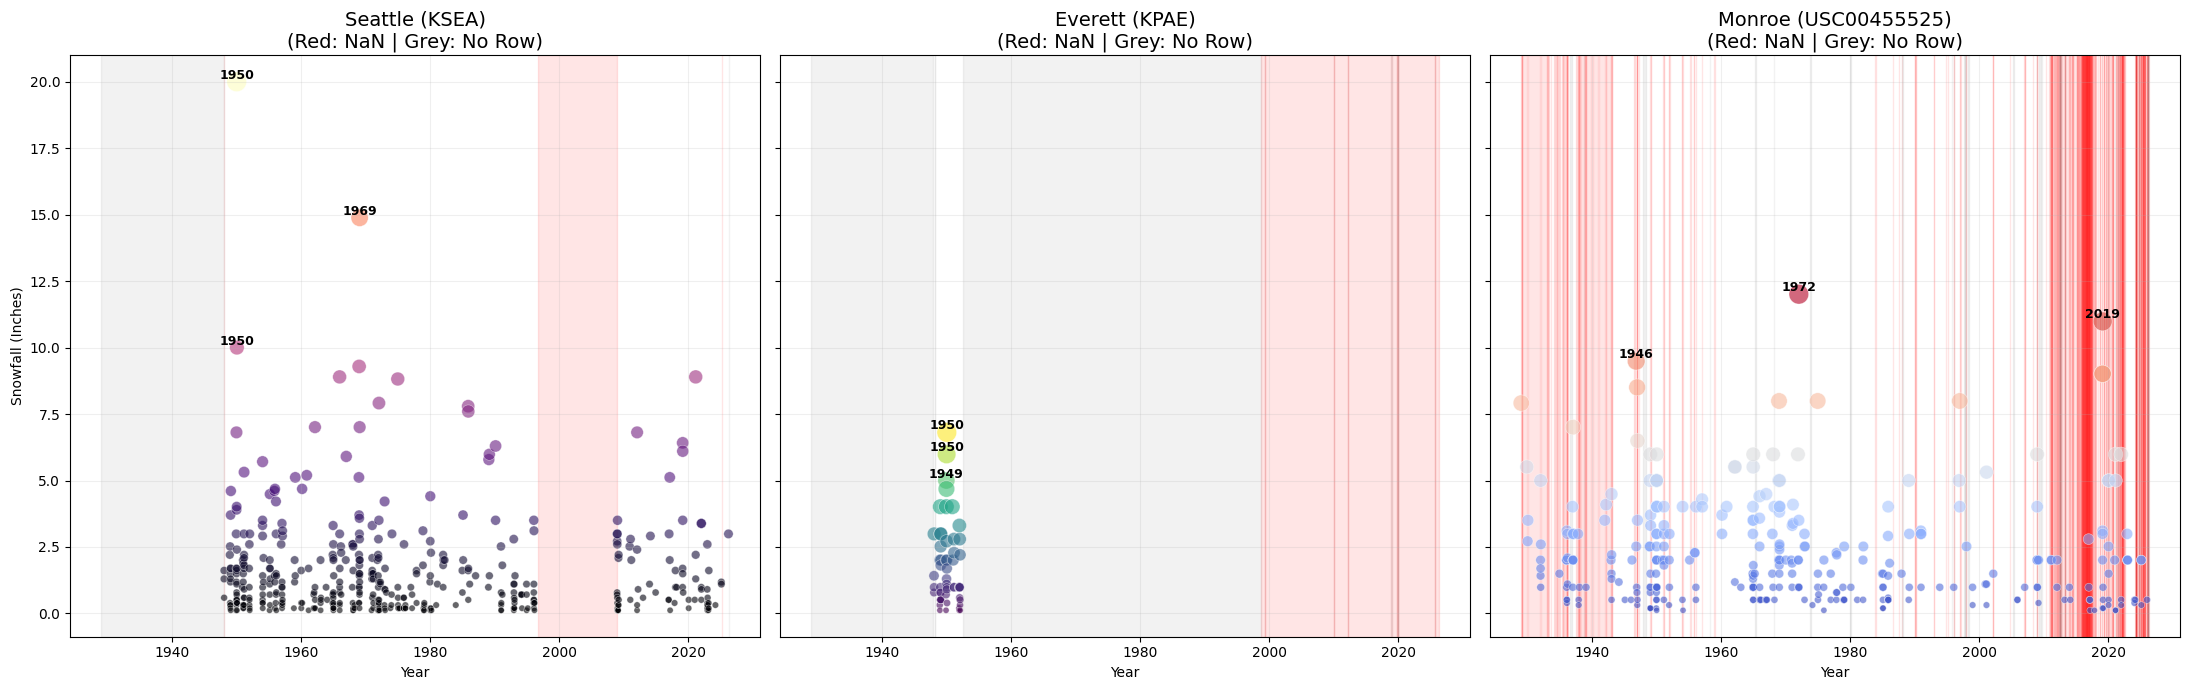

In [10]:
# 1. Visualization settings (1 row, 3 columns structure, sharex=True)
fig, axes = plt.subplots(1, 3, figsize=(22, 7), sharey=True, sharex=True)

stations_data = [
    (df_seattle_raw, 'Seattle (KSEA)', 'magma'),
    (df_everett_raw, 'Everett (KPAE)', 'viridis'),
    (df_monroe_raw, 'Monroe (USC00455525)', 'coolwarm')
]

# Calculate common start and end dates for the entire dataset
all_min_date = min(d['DATE'].min() for d, _, _ in stations_data)
all_max_date = max(d['DATE'].max() for d, _, _ in stations_data)
full_range = pd.date_range(all_min_date, all_max_date)

for i, (data, title, cmap) in enumerate(stations_data):
    # Data for scatter plot: only days with snowfall
    snow_events = data[data['SNOW_INCH'] > 0][['DATE', 'SNOW_INCH']].dropna()

    # 1. Find sections with 'NaN' data (rows exist but SNOW is missing)
    # 2. Find sections with 'No Data' (rows themselves are missing)
    # Logic to calculate continuous sections for axvspan
    data_sorted = data.sort_values('DATE').set_index('DATE')

    # Reindex for the entire period to distinguish between NaN and missing rows
    full_data = pd.DataFrame(index=full_range)
    full_data['SNOW'] = data_sorted['SNOW']
    full_data['exists'] = full_data.index.isin(data_sorted.index)

    # Function to plot intervals for visualization
    def plot_intervals(series, color, label_alpha):
        diff = series.astype(int).diff().fillna(0)
        starts = series[ (series == True) & (series.shift(1) != True) ].index
        ends = series[ (series == True) & (series.shift(-1) != True) ].index
        for s, e in zip(starts, ends):
            axes[i].axvspan(s, e, color=color, alpha=label_alpha, zorder=0)

    # NaN sections (red)
    is_nan = full_data['exists'] & full_data['SNOW'].isna()
    plot_intervals(is_nan, 'red', 0.1)

    # Missing data sections (grey)
    is_missing = ~full_data['exists']
    plot_intervals(is_missing, 'grey', 0.1)

    # Draw scatter plot
    sns.scatterplot(ax=axes[i], x='DATE', y='SNOW_INCH', data=snow_events,
                    s=80, hue='SNOW_INCH', size='SNOW_INCH', sizes=(20, 200),
                    palette=cmap, legend=False, alpha=0.6)

    # Display top 3 records
    top_3 = snow_events.nlargest(3, 'SNOW_INCH')
    for _, row in top_3.iterrows():
        axes[i].text(row['DATE'], row['SNOW_INCH'], f"{row['DATE'].strftime('%Y')}",
                     fontsize=9, fontweight='bold', ha='center', va='bottom')

    axes[i].set_title(f'{title}\n(Red: NaN | Grey: No Row)', fontsize=14)
    axes[i].set_xlabel('Year')
    axes[i].grid(True, alpha=0.2)

axes[0].set_ylabel('Snowfall (Inches)')
plt.tight_layout()
plt.show()

In [11]:
# Extract representative coordinates for each station
stations = [
    {'name': 'Seattle (KSEA)', 'lat': df_seattle_raw['LATITUDE'].iloc[0], 'lon': df_seattle_raw['LONGITUDE'].iloc[0], 'color': 'red'},
    {'name': 'Everett (KPAE)', 'lat': df_everett_raw['LATITUDE'].iloc[0], 'lon': df_everett_raw['LONGITUDE'].iloc[0], 'color': 'blue'},
    {'name': 'Monroe (USC00455525)', 'lat': df_monroe_raw['LATITUDE'].iloc[0], 'lon': df_monroe_raw['LONGITUDE'].iloc[0], 'color': 'green'}
]

# Use 'CartoDB positron' tiles for better county boundary visibility
m = folium.Map(location=[47.7, -122.1], zoom_start=9, tiles='CartoDB positron')


# Add markers
for s in stations:
    folium.Marker(
        location=[s['lat'], s['lon']],
        popup=s['name'],
        tooltip=s['name'],
        icon=folium.Icon(color=s['color'], icon='info-sign')
    ).add_to(m)

# Display the map
display(m)